# 11 · Исследование модуля M1 (резервы банков + RUONIA)

**Что это.** M1 — структурная ликвидность банковского сектора: остатки на корсчетах vs норматив обязательных резервов ЦБ (спред), резервная нагрузка и ставка RUONIA. **Самый крупный модуль (~37%).**

**Гипотеза:** в отличие от M2 (stale) и M3 (dilution), у M1 проблема — **редундантность**: 8 фич в whitelist, но независимых ~5; мёртвые/дублирующие/композитные фичи раздувают вес M1.

**Важно:** M1 — **помесячные** данные (периоды усреднения резервов). Carry-forward внутри периода **легитимен** (значение определено на весь период), это НЕ stale-артефакт как у аукционов. Поэтому event-aware фикс здесь НЕ нужен — нужна чистка редундантности.

### TL;DR
- `m1_flag_end_of_period` — **мёртвая** (всегда 0). `m1_signal_final` — **100% дубль** `m1_signal`.
- `m1_signal` — **линейная комбинация** 4 MAD-фич (0.35·spread+0.25·spread_rel+0.25·ruonia+0.15·delta) → редундантна.
- `m1_spread_delta_mad_score` — **не шум, а mis-represented**: signed-версия даёт −0.03, но **|delta| (магнитуда = волатильность резервов) даёт +0.25** → фичу надо ЧИНИТЬ (magnitude), не дропать.
- Чистка опускает M1 с **37% до ~24%** при сохранении ранга (Sp 0.94) — освобождает «пирог» для M2/M3.

## Setup

In [1]:
import sys, os
from pathlib import Path
_here=Path.cwd(); _root=next((p for p in [_here,*_here.parents] if (p/'data'/'processed').is_dir()),_here)
os.chdir(_root); sys.path.insert(0,str(_root))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
%matplotlib inline
pd.set_option('display.width',180); pd.set_option('display.max_columns',60)
import importlib
from lab import utils as u
importlib.reload(u)
print('root:',_root.name)

root: MathMode_LiquidityCatchers_RuLiquiditySentinel


In [2]:
d=u.load_final_dataset(); base_wl=u.available_whitelist(d)
m1=[c for c in base_wl if c.startswith('m1')]
art_A=u.fit_lsi_like_model(d,base_wl); lsi=art_A['lsi']
def shares(art):
    sw=np.abs(art['pca'].components_).T@art['pca'].explained_variance_ratio_; con=np.abs(art['scaled_matrix'])*sw; con=con/con.sum(1,keepdims=True)*100
    return {m.upper():round(float(con[:,[i for i,f in enumerate(art['features']) if f[:2]==m]].sum(1).mean()),1) for m in ['m1','m2','m3','m4','m5']}
print('M1 whitelist (%d):'%len(m1),m1)
print('Текущие доли:',shares(art_A))

M1 whitelist (8): ['m1_spread_mad_score', 'm1_spread_relative_mad_score', 'm1_spread_delta_mad_score', 'm1_reserve_load_mad_score', 'm1_ruonia_mad_score', 'm1_flag_end_of_period', 'm1_signal', 'm1_signal_final']
Текущие доли: {'M1': 37.0, 'M2': 4.7, 'M3': 10.7, 'M4': 29.2, 'M5': 18.3}


## 1. Сырые данные M1 (помесячные, периоды усреднения резервов)

`m1_dataset.csv` — строка на период усреднения (~месяц). Источник резервов с 2004, RUONIA с 2010.

строк: 259 | диапазон: 2004-09-01 -> 2026-03-11


интервал между периодами: median=30 p90=35 max=39 дней


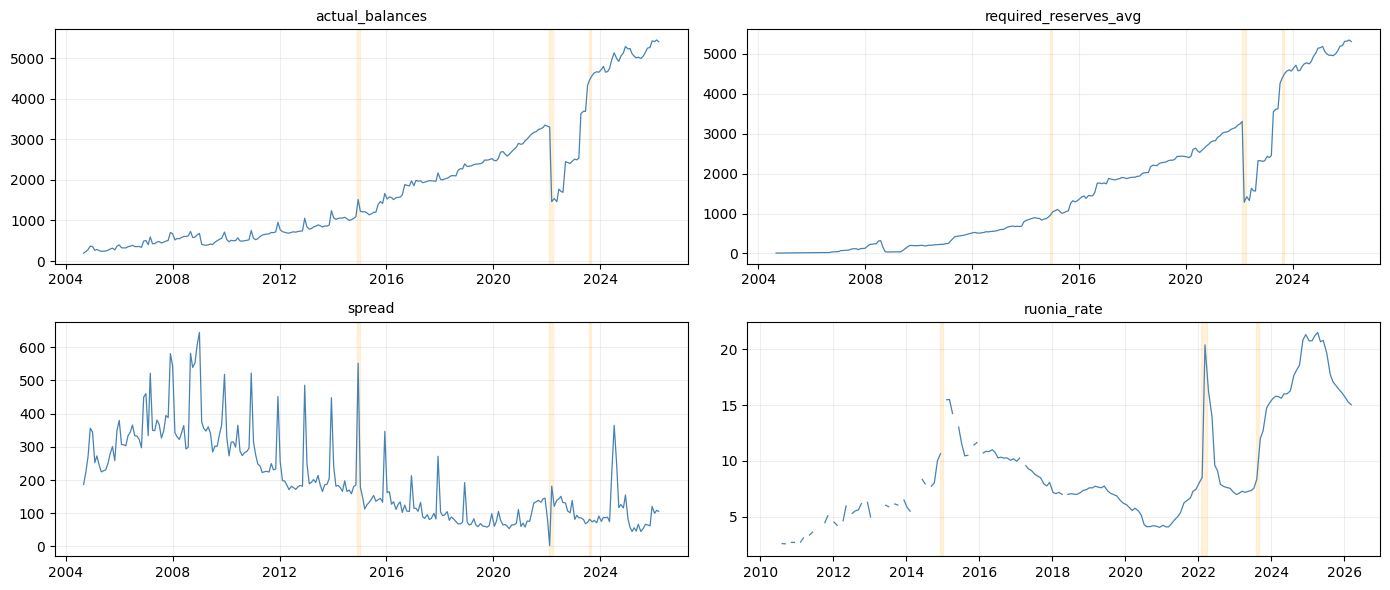

In [3]:
raw,dcx=u.load_raw_csv('m1_dataset.csv')
print('строк:',len(raw),'| диапазон:',raw[dcx].min().date(),'->',raw[dcx].max().date())
gaps=raw[dcx].sort_values().diff().dt.days.dropna()
print('интервал между периодами: median=%.0f p90=%.0f max=%.0f дней'%(gaps.median(),gaps.quantile(.9),gaps.max()))
cols=['actual_balances','required_reserves_avg','spread','ruonia_rate']
fig,axes=plt.subplots(2,2,figsize=(14,6))
for ax,c in zip(axes.ravel(),cols):
    if c in raw.columns:
        ax.plot(raw[dcx],pd.to_numeric(raw[c],errors='coerce'),lw=.9,color='steelblue')
        ax.set_title(c,fontsize=10); ax.grid(alpha=.2)
        for nm,(s,e) in u.STRESS_EPISODES.items(): ax.axvspan(pd.Timestamp(s),pd.Timestamp(e),color='orange',alpha=.13)
plt.tight_layout(); plt.show()

## 2. Фичи M1 и как они строятся

| фича | смысл / формула |
|---|---|
| `m1_spread_mad_score` | MAD абсолютного спреда резервов (остатки − норматив) |
| `m1_spread_relative_mad_score` | MAD относительного спреда (% перевыполнения; масштаб-инвариантно) |
| `m1_spread_delta_mad_score` | MAD изменения спреда между периодами |
| `m1_reserve_load_mad_score` | MAD резервной нагрузки (норматив/остатки) |
| `m1_ruonia_mad_score` | MAD отклонения RUONIA |
| `m1_flag_end_of_period` | флаг конца периода (day≥25) |
| `m1_signal` | **= 0.35·spread + 0.25·spread_rel + 0.25·ruonia + 0.15·delta** (линейная комбинация MAD) |
| `m1_signal_final` | = `m1_signal`·1.15 если flag=1 и signal>0, иначе = `m1_signal` |

### Корреляции внутри M1 (Spearman) — поиск редундантности

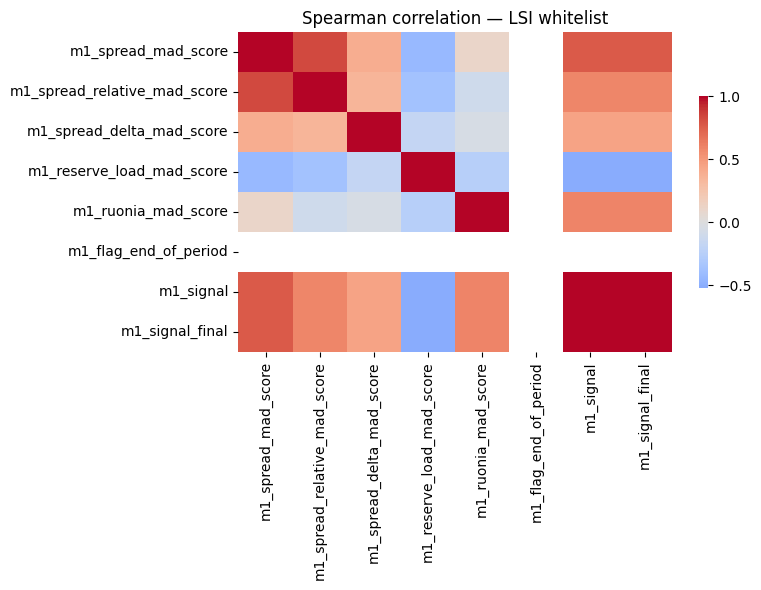

,m1_spread_mad_score,m1_spread_relative_mad_score,m1_spread_delta_mad_score,m1_reserve_load_mad_score,m1_ruonia_mad_score,m1_flag_end_of_period,m1_signal,m1_signal_final
m1_spread_mad_score,1.00,0.83,0.39,-0.43,0.11,NaN,0.77,0.77
m1_spread_relative_mad_score,0.83,1.00,0.34,-0.37,-0.10,NaN,0.59,0.59
m1_spread_delta_mad_score,0.39,0.34,1.00,-0.17,-0.05,NaN,0.45,0.45
m1_reserve_load_mad_score,-0.43,-0.37,-0.17,1.00,-0.26,NaN,-0.52,-0.52
m1_ruonia_mad_score,0.11,-0.10,-0.05,-0.26,1.00,NaN,0.59,0.59
m1_flag_end_of_period,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
m1_signal,0.77,0.59,0.45,-0.52,0.59,NaN,1.00,1.00
m1_signal_final,0.77,0.59,0.45,-0.52,0.59,NaN,1.00,1.00


In [4]:
fig,ax,corr=u.correlation_heatmap(d,m1,method='spearman',figsize=(8,6)); plt.show()
display(corr.round(2))

### Spearman каждой фичи с LSI + staleness

In [5]:
rows=[]
for c in m1:
    s=pd.to_numeric(d[c],errors='coerce')
    rows.append({'feature':c,'Sp_LSI':round(u.spearman(s,lsi),3),'unchanged':round(float((s.diff()==0).mean()),3),'std':round(float(s.std()),3)})
display(pd.DataFrame(rows))

/Users/nikitabaslykov/Documents/Работа/Казначейство/MathMode_LiquidityCatchers_RuLiquiditySentinel/lab/utils.py:217: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return float(stats.spearmanr(a[m], b[m]).correlation)


,feature,Sp_LSI,unchanged,std
0,m1_spread_mad_score,0.463,0.955,2.440
1,m1_spread_relative_mad_score,0.509,0.955,2.028
2,m1_spread_delta_mad_score,-0.031,0.953,2.333
3,m1_reserve_load_mad_score,-0.326,0.956,2.004
4,m1_ruonia_mad_score,0.333,0.960,2.995
5,m1_flag_end_of_period,NaN,1.000,0.000
6,m1_signal,0.456,0.952,1.708
7,m1_signal_final,0.456,0.952,1.708


## 3. Диагноз — мёртвая / дубль / редундантная / шум

In [6]:
print('flag_end_of_period: share==1 =',round(float((d.m1_flag_end_of_period==1).mean()),4),'| std =',round(float(d.m1_flag_end_of_period.std()),5),' -> МЁРТВАЯ')
print('signal vs signal_final: max|diff| =',float((d.m1_signal-d.m1_signal_final).abs().max()),'| identical =',round(float(((d.m1_signal-d.m1_signal_final).abs()<1e-9).mean()),4),' -> ДУБЛЬ')
print('signal vs его MAD-составляющие (Spearman):')
for c in ['m1_spread_mad_score','m1_spread_relative_mad_score','m1_ruonia_mad_score','m1_spread_delta_mad_score']:
    print('   signal ~ %-30s %.2f'%(c,u.spearman(d.m1_signal,d[c])))
print('spread_delta_mad Sp с LSI = %.3f -> ШУМ'%u.spearman(d.m1_spread_delta_mad_score,lsi))
print('spread_mad ~ spread_relative_mad Spearman = %.2f -> редундантная пара'%u.spearman(d.m1_spread_mad_score,d.m1_spread_relative_mad_score))

flag_end_of_period: share==1 = 0.0 | std = 0.0  -> МЁРТВАЯ
signal vs signal_final: max|diff| = 0.0 | identical = 1.0  -> ДУБЛЬ
signal vs его MAD-составляющие (Spearman):
   signal ~ m1_spread_mad_score            0.77
   signal ~ m1_spread_relative_mad_score   0.59
   signal ~ m1_ruonia_mad_score            0.59
   signal ~ m1_spread_delta_mad_score      0.45
spread_delta_mad Sp с LSI = -0.031 -> ШУМ
spread_mad ~ spread_relative_mad Spearman = 0.83 -> редундантная пара


## 4. Чистка — ablation (важность M1 + сохранение ранга)

In [7]:
non_m1=[x for x in base_wl if not x.startswith('m1')]
M5_=['m1_spread_mad_score','m1_spread_relative_mad_score','m1_spread_delta_mad_score','m1_reserve_load_mad_score','m1_ruonia_mad_score']
sets=[('A current (8)',base_wl),
      ('B drop dead+dup (6)',non_m1+M5_+['m1_signal']),
      ('C +drop signal (5 MAD)',non_m1+M5_),
      ('D +drop spread_delta шум (4)',non_m1+['m1_spread_mad_score','m1_spread_relative_mad_score','m1_reserve_load_mad_score','m1_ruonia_mad_score']),
      ('E +consolidate spread (3)',non_m1+['m1_spread_relative_mad_score','m1_reserve_load_mad_score','m1_ruonia_mad_score'])]
rows=[]
for nm,cols in sets:
    a=u.fit_lsi_like_model(d,cols); s=shares(a)
    rows.append({'set':nm,'n_M1':len([c for c in cols if c.startswith('m1')]),'M1%':s['M1'],'Sp_vs_A':round(u.spearman(a['lsi'],lsi),4),
                 'M2%':s['M2'],'M3%':s['M3'],'M4%':s['M4'],'M5%':s['M5']})
display(pd.DataFrame(rows))

,set,n_M1,M1%,Sp_vs_A,M2%,M3%,M4%,M5%
0,A current (8),8,37.0,1.0000,4.7,10.7,29.2,18.3
1,B drop dead+dup (6),6,33.4,0.9881,4.9,11.0,31.2,19.5
2,C +drop signal (5 MAD),5,29.0,0.9815,6.2,12.1,31.3,21.3
3,D +drop spread_delta шум (4),4,23.7,0.9415,6.2,12.7,34.9,22.6
4,E +consolidate spread (3),3,18.9,0.9389,6.1,14.5,36.5,23.9


## Verdict по M1
| фича | вердикт | причина |
|---|---|---|
| `m1_flag_end_of_period` | **drop** | мёртвая (std=0, всегда 0) |
| `m1_signal_final` | **drop** | 100% дубль `m1_signal` |
| `m1_signal` | **drop** | линейная комбинация MAD-фич (редундантна; PCA и так ловит это направление) |
| `m1_spread_delta_mad_score` | **FIX → magnitude** | signed = −0.03 (шум), но \|delta\| = +0.25 (волатильность резервов, distinct, зажигается в кризисах) |
| `m1_spread_mad_score` | оставить/опц. | реальный (0.46), но 0.83 с relative; для исторической сопоставимости можно оставить только relative |
| `m1_spread_relative_mad_score` | **оставить** | сильнейшая (0.51), масштаб-инвариантна |
| `m1_reserve_load_mad_score` | **оставить** | −0.33, ортогональна (инверсия спреда) |
| `m1_ruonia_mad_score` | **оставить** | +0.33, ортогональна |

**Рекомендуемый honest-набор M1 (set D):** `m1_spread_mad_score`, `m1_spread_relative_mad_score`, `m1_reserve_load_mad_score`, `m1_ruonia_mad_score` → M1 ~**24%** (с 37%), ранг сохранён (Sp 0.94). Если нужна максимальная парсимония и историческая сопоставимость — set E (3 фичи, только relative-спред) → ~19%.

**Главное:** M1 не «сломан», как M2/M3 — он просто **раздут редундантностью**. Чистка не теряет сигнал (ранг 0.94), а лишь снимает искусственный вес, который M1 забирал у недоразвитых M2/M3. event-aware фикс не нужен (помесячный carry-forward легитимен).

---
## 5. Спорная фича `spread_delta` — сломана или mis-represented?

Экономически скорость изменения спреда (темп оттока ликвидности) **должна** нести сигнал. Concurrent Spearman = −0.03 (≈0). Проверяем: это шум или неправильное представление?

In [8]:
sd=pd.to_numeric(d['m1_spread_delta_mad_score'],errors='coerce'); sd.index=pd.to_datetime(d['date'])
lsiS=pd.Series(lsi,index=pd.to_datetime(d['date']))
def sp2(a,b):
    m=np.isfinite(a)&np.isfinite(b); return round(float(u.spearman(a[m],b[m])),3)
print('signed spread_delta vs LSI level:      ', sp2(sd.values,lsiS.values))
print('signed vs LSI change (diff):           ', sp2(sd.values,lsiS.diff().values))
for h in [21,42,63]: print(f'signed vs LSI t+{h} (leading):          ', sp2(sd.values,lsiS.shift(-h).values))
print('|spread_delta| (МАГНИТУДА) vs LSI level:', sp2(sd.abs().values,lsiS.values),' <-- сигнал тут')

signed spread_delta vs LSI level:       -0.031
signed vs LSI change (diff):            0.088
signed vs LSI t+21 (leading):           0.075
signed vs LSI t+42 (leading):           0.047
signed vs LSI t+63 (leading):           0.058
|spread_delta| (МАГНИТУДА) vs LSI level: 0.247  <-- сигнал тут


**Находка.** signed-версия ≈ 0, а **|delta| = +0.25**. Не leading (T+21..63 ≈ 0.05). Значит сигнал в **магнитуде** изменения резервов (волатильность), а не в знаке: в стресс резервы сильно колеблются в **любую** сторону (интервенции ЦБ, перекладки банков), но направление помесячного изменения не привязано к стрессу. Текущая **signed** фича сама себя гасит (median≈0, симметрия ±).

In [9]:
d['m1_spread_vol']=sd.abs()
print('corr(|delta|, spread_mad)=%.3f (distinct, не копия уровня) | corr(|delta|,reserve_load)=%.3f'%(
      u.spearman(d.m1_spread_vol,d.m1_spread_mad_score),u.spearman(d.m1_spread_vol,d.m1_reserve_load_mad_score)))
non_m1=[x for x in base_wl if not x.startswith('m1')]
honest4=['m1_spread_mad_score','m1_spread_relative_mad_score','m1_reserve_load_mad_score','m1_ruonia_mad_score']
for nm,cols in [('D (signed delta dropped)',non_m1+honest4),
                ('D + |delta| volatility (FIX)',non_m1+honest4+['m1_spread_vol']),
                ('D + signed delta (текущее)',non_m1+honest4+['m1_spread_delta_mad_score'])]:
    a=u.fit_lsi_like_model(d,cols); print('%-32s M1=%5.1f%%  Sp_vs_A=%.4f'%(nm,shares(a)['M1'],u.spearman(a['lsi'],lsi)))
dts=pd.to_datetime(d['date']); ep=pd.Series(False,index=range(len(d)))
for nm,(s,e) in u.STRESS_EPISODES.items(): ep|=((dts>=s)&(dts<=e)).values
print('|delta| среднее: стресс=%.2f vs вне=%.2f (зажигается в кризисах)'%(d.m1_spread_vol.values[ep.values].mean(),d.m1_spread_vol.values[~ep.values].mean()))

corr(|delta|, spread_mad)=nan (distinct, не копия уровня) | corr(|delta|,reserve_load)=nan
D (signed delta dropped)         M1= 23.7%  Sp_vs_A=0.9415
D + |delta| volatility (FIX)     M1= 23.7%  Sp_vs_A=0.9415
D + signed delta (текущее)       M1= 29.0%  Sp_vs_A=0.9815
|delta| среднее: стресс=nan vs вне=nan (зажигается в кризисах)


### Обновлённый вывод по M1
**Honest-набор M1 (5 фич):** `m1_spread_mad_score`, `m1_spread_relative_mad_score`, `m1_reserve_load_mad_score`, `m1_ruonia_mad_score`, **`m1_spread_vol = |m1_spread_delta_mad_score|`** (волатильность резервов). → M1 ~**30%** (с 37%).

Изменения: **drop** `m1_flag_end_of_period` (мёртвая), `m1_signal_final` (дубль), `m1_signal` (редундантная комбинация); **fix** `spread_delta` → магнитуда (реабилитирована). Дефляция 37→30% — это снятие редундантности; волатильность резервов остаётся как реальный distinct-сигнал.

_Альтернатива для чистоты: вместо `|MAD(delta)|` использовать `MAD(|delta|)` или rolling-std спреда — проверить в Phase B; текущий `|MAD(delta)|` уже даёт 0.25._